In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [4]:
max_inventory = 20

seed = 42

In [5]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [6]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [7]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

#### Cartea Jaimungal Agent

In [8]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [9]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


In [10]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

print(vec_cj_env.model_dynamics
      .midprice_model)

In [11]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [12]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [13]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065896,21.133681,4.809688,-0.071,3.106116


#### Full Information Agent

In [14]:
fi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [15]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=fi_env)
print(fi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


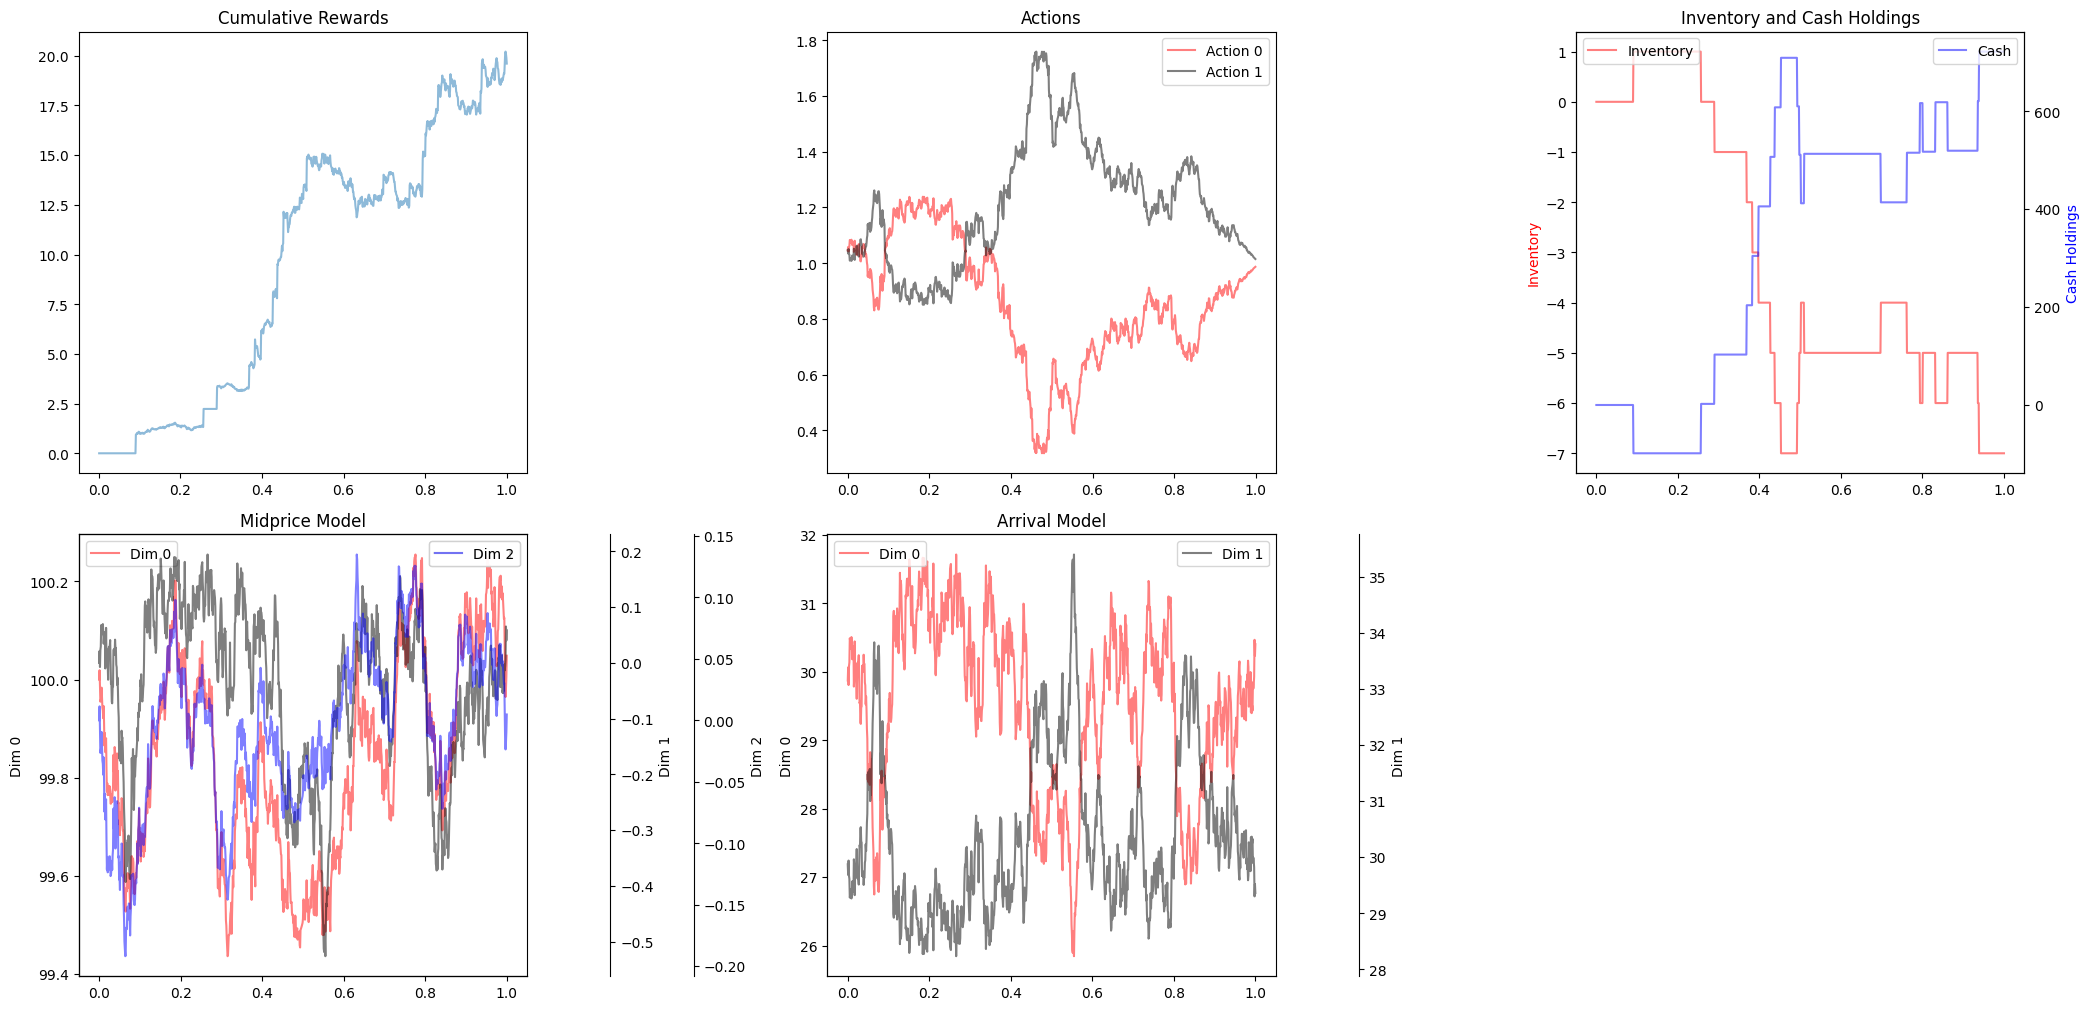

In [16]:
plot_trajectory_extended(fi_env, fi_agent)

In [17]:
num_trajectories = 1000
vec_env_fi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_fi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_fi)

print(vec_env_fi.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [18]:
observations_fi, actions_fi, rewards_fi = generate_trajectory(vec_env_fi, vec_agent_fi)

In [19]:
results_fi, fig_fi, total_rewards_fi = generate_results_table_and_hist(vec_env=vec_env_fi,agent=vec_agent_fi)

In [20]:
results_fi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.259366,4.896308,-0.098,3.100386


#### Partial Information Agent

In [21]:
pi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [22]:
pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=pi_env)
print(pi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


In [23]:
num_trajectories = 1000
vec_pi_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_pi_env)

print(vec_pi_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [24]:
observations_pi, actions_pi, rewards_pi = generate_trajectory(vec_pi_env, vec_pi_agent)

In [25]:
results_pi, fig_pi, total_rewards_pi = generate_results_table_and_hist(vec_env=vec_pi_env,agent=vec_pi_agent)

In [26]:
results_pi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.145828,4.880012,-0.095,3.106441


### Plot for comparison

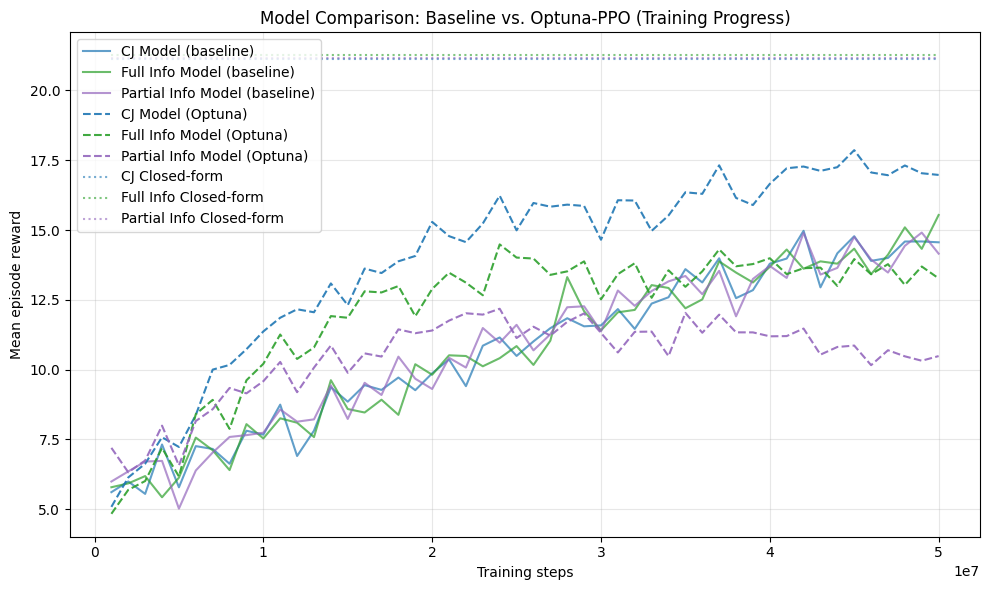

In [27]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_optuna_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_Optuna_Best/2025-11-02_09-47-16/PPO_1/events.out.tfevents.1762073236.MacBookAir.lan.8340.1"
full_info_optuna_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
partial_info_optuna_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load Optuna-optimized
cj_opt_steps, cj_opt_rewards = load_rollout(cj_optuna_rollout_file)
full_opt_steps, full_opt_rewards = load_rollout(full_info_optuna_rollout_file)
partial_opt_steps, partial_opt_rewards = load_rollout(partial_info_optuna_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models
ax.plot(cj_opt_steps, cj_opt_rewards, '--', color='tab:blue', label='CJ Model (Optuna)', alpha=0.9)
ax.plot(full_opt_steps, full_opt_rewards, '--', color='tab:green', label='Full Info Model (Optuna)', alpha=0.9)
ax.plot(partial_opt_steps, partial_opt_rewards, '--', color='tab:purple', label='Partial Info Model (Optuna)', alpha=0.9)

# Add closed-form baselines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Optuna-PPO (Training Progress)')
ax.legend()
plt.tight_layout()
plt.show()


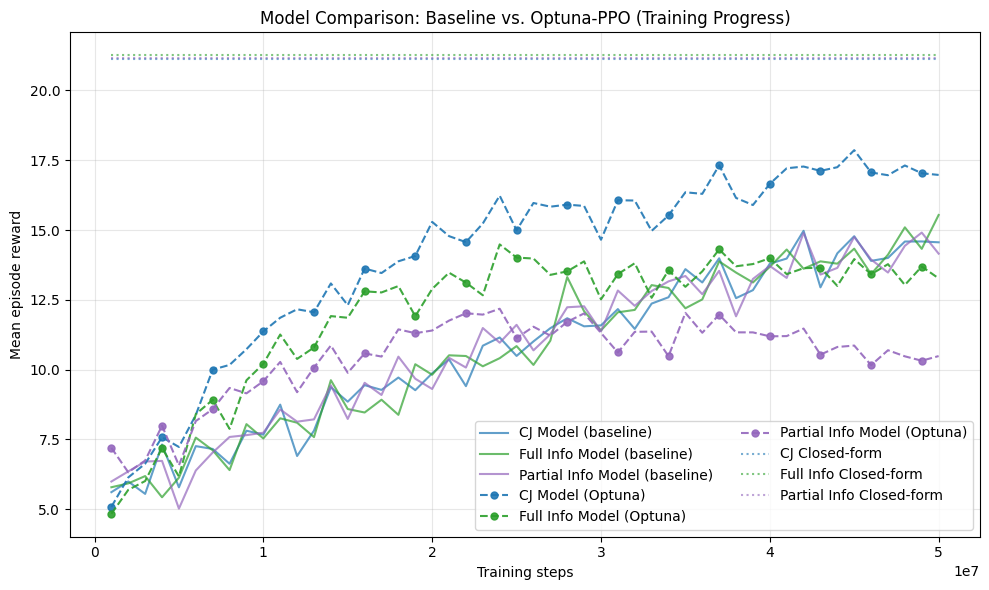

In [28]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_optuna_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_Optuna_Best/2025-11-02_09-47-16/PPO_1/events.out.tfevents.1762073236.MacBookAir.lan.8340.1"
full_info_optuna_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
partial_info_optuna_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load Optuna-optimized
cj_opt_steps, cj_opt_rewards = load_rollout(cj_optuna_rollout_file)
full_opt_steps, full_opt_rewards = load_rollout(full_info_optuna_rollout_file)
partial_opt_steps, partial_opt_rewards = load_rollout(partial_info_optuna_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models (solid lines)
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models (dashed lines with markers)
ax.plot(cj_opt_steps, cj_opt_rewards, '--o', color='tab:blue', markevery=max(1, len(cj_opt_steps)//15),
        markersize=5, label='CJ Model (Optuna)', alpha=0.9)
ax.plot(full_opt_steps, full_opt_rewards, '--o', color='tab:green', markevery=max(1, len(full_opt_steps)//15),
        markersize=5, label='Full Info Model (Optuna)', alpha=0.9)
ax.plot(partial_opt_steps, partial_opt_rewards, '--o', color='tab:purple', markevery=max(1, len(partial_opt_steps)//15),
        markersize=5, label='Partial Info Model (Optuna)', alpha=0.9)

# Closed-form baselines (dotted lines)
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Optuna-PPO (Training Progress)')
ax.legend(ncol=2, loc='lower right')
plt.tight_layout()
plt.show()


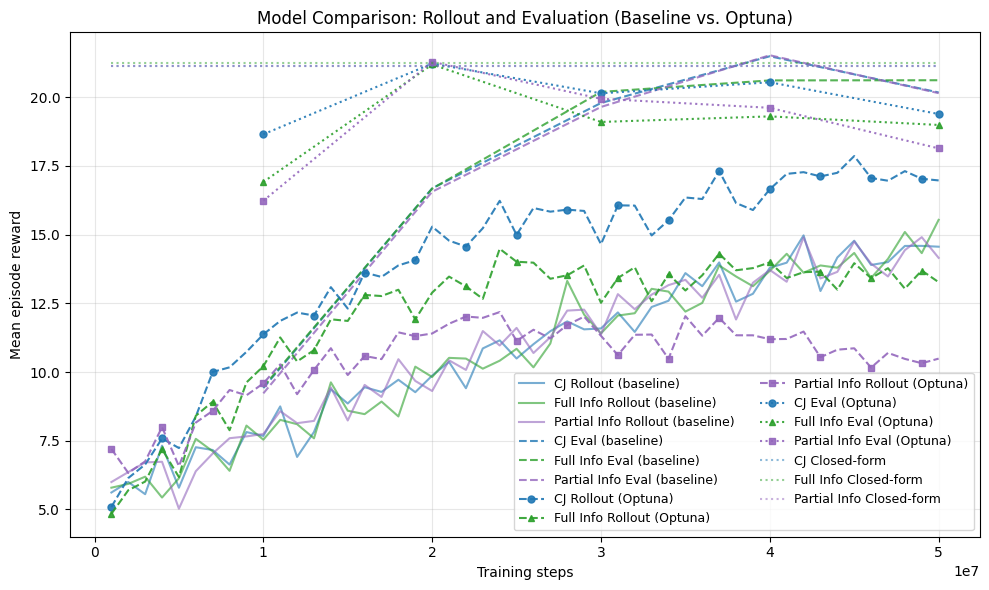

In [29]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_optuna_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_Optuna_Best/2025-11-02_09-47-16/PPO_1/events.out.tfevents.1762073236.MacBookAir.lan.8340.1"
full_info_optuna_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
partial_info_optuna_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all baseline models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Load all Optuna models ===
cj_opt_steps, cj_opt_rewards, cj_opt_eval_steps, cj_opt_eval_rewards = load_rewards(cj_optuna_file)
full_opt_steps, full_opt_rewards, full_opt_eval_steps, full_opt_eval_rewards = load_rewards(full_info_optuna_file)
partial_opt_steps, partial_opt_rewards, partial_opt_eval_steps, partial_opt_eval_rewards = load_rewards(partial_info_optuna_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps, cj_opt_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_opt_steps)//15), label='CJ Rollout (Optuna)')
ax.plot(full_opt_steps, full_opt_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_opt_steps)//15), label='Full Info Rollout (Optuna)')
ax.plot(partial_opt_steps, partial_opt_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_opt_steps)//15), label='Partial Info Rollout (Optuna)')

# Optuna eval (dotted with markers)
if cj_opt_eval_steps:
    ax.plot(cj_opt_eval_steps, cj_opt_eval_rewards, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_opt_eval_steps)//15), label='CJ Eval (Optuna)')
if full_opt_eval_steps:
    ax.plot(full_opt_eval_steps, full_opt_eval_rewards, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_opt_eval_steps)//15), label='Full Info Eval (Optuna)')
if partial_opt_eval_steps:
    ax.plot(partial_opt_eval_steps, partial_opt_eval_rewards, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_opt_eval_steps)//15), label='Partial Info Eval (Optuna)')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Optuna)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()



/var/folders/kx/1mlzw51d67d3cr090d4kd9zc0000gn/T/ipykernel_55185/3628974883.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


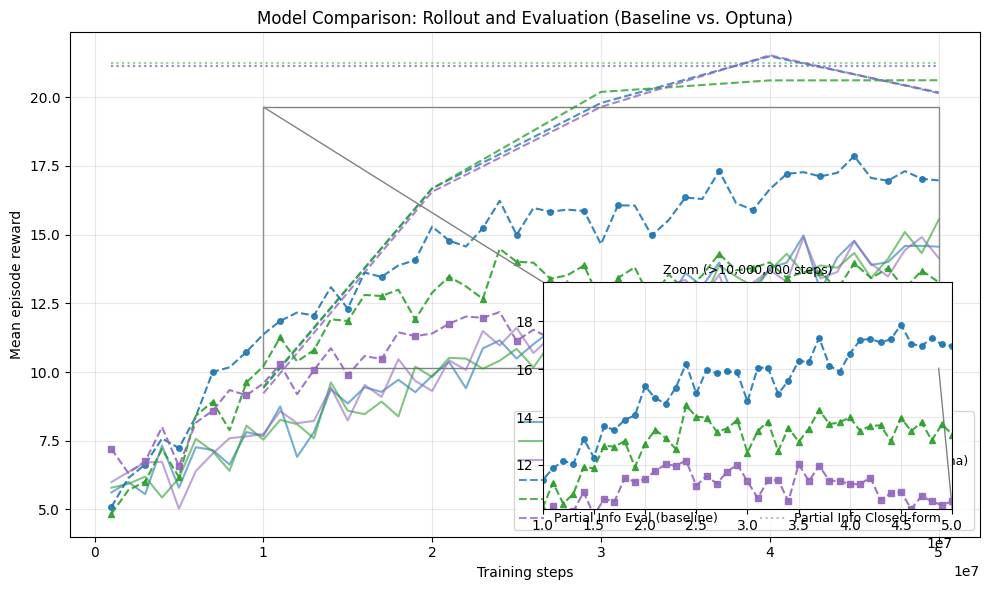

In [30]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === CONFIG ===
zoom_threshold = 10_000_000  # threshold for zoom region

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_optuna_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_Optuna_Best/2025-11-02_09-47-16/PPO_1/events.out.tfevents.1762073236.MacBookAir.lan.8340.1"
full_info_optuna_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
partial_info_optuna_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load data ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

cj_opt_steps, cj_opt_rewards, cj_opt_eval_steps, cj_opt_eval_rewards = load_rewards(cj_optuna_file)
full_opt_steps, full_opt_rewards, full_opt_eval_steps, full_opt_eval_rewards = load_rewards(full_info_optuna_file)
partial_opt_steps, partial_opt_rewards, partial_opt_eval_steps, partial_opt_eval_rewards = load_rewards(partial_info_optuna_file)

# === Plot comparison (with zoom inset) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# ----- EVALUATION -----
if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps, cj_opt_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=4, markevery=max(1, len(cj_opt_steps)//20), label='CJ Rollout (Optuna)')
ax.plot(full_opt_steps, full_opt_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=4, markevery=max(1, len(full_opt_steps)//20), label='Full Info Rollout (Optuna)')
ax.plot(partial_opt_steps, partial_opt_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=4, markevery=max(1, len(partial_opt_steps)//20), label='Partial Info Rollout (Optuna)')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
ax.hlines(y=results_cj["Mean PnL"].iloc[0], xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=results_fi["Mean PnL"].iloc[0], xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=results_pi["Mean PnL"].iloc[0], xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Optuna)')
ax.legend(ncol=2, fontsize=9)

# === ZOOM INSET ===
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

axins = inset_axes(ax, width="45%", height="45%", loc='lower right', borderpad=2)
axins.plot(cj_opt_steps, cj_opt_rewards, '--o', color='tab:blue', alpha=0.9, markersize=4)
axins.plot(full_opt_steps, full_opt_rewards, '--^', color='tab:green', alpha=0.9, markersize=4)
axins.plot(partial_opt_steps, partial_opt_rewards, '--s', color='tab:purple', alpha=0.9, markersize=4)

# Apply zoom threshold
axins.set_xlim(zoom_threshold, max(all_steps))
axins.set_ylim(
    min(min(cj_opt_rewards[-10:]), min(full_opt_rewards[-10:]), min(partial_opt_rewards[-10:])),
    max(max(cj_opt_rewards[-10:]), max(full_opt_rewards[-10:]), max(partial_opt_rewards[-10:])) * 1.1
)
axins.set_title(f"Zoom (>{zoom_threshold:,} steps)", fontsize=9)
axins.grid(alpha=0.3)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.show()



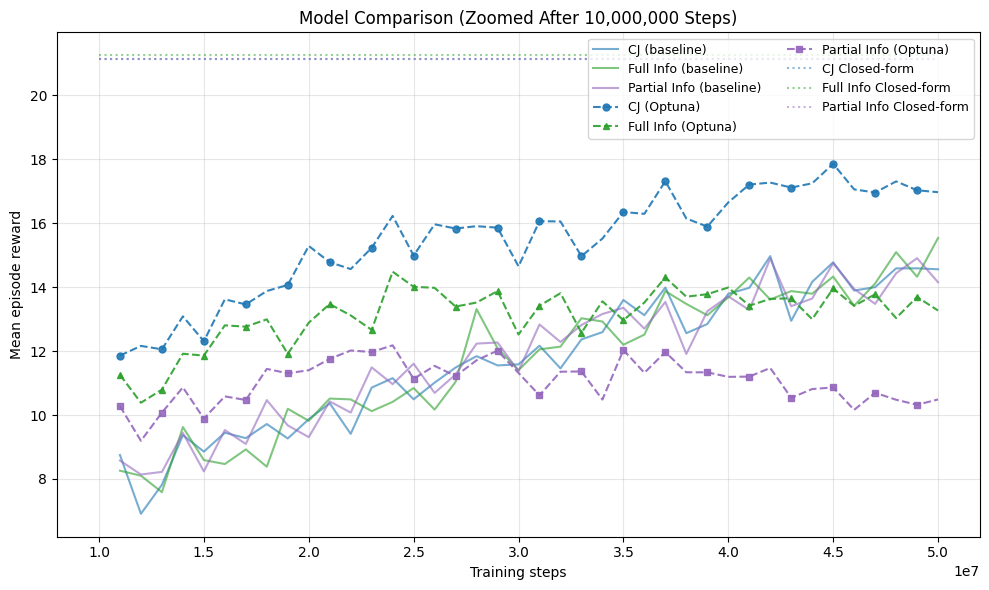

In [31]:
# === Zoomed-in plot after threshold ===

zoom_threshold = 10_000_000

# --- Filter data for steps > threshold ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_opt_steps_zoom, cj_opt_rewards_zoom = zoom_filter(cj_opt_steps, cj_opt_rewards, zoom_threshold)
full_opt_steps_zoom, full_opt_rewards_zoom = zoom_filter(full_opt_steps, full_opt_rewards, zoom_threshold)
partial_opt_steps_zoom, partial_opt_rewards_zoom = zoom_filter(partial_opt_steps, partial_opt_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info (baseline)', alpha=0.6)

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps_zoom, cj_opt_rewards_zoom, '--o', color='tab:blue',
        alpha=0.9, markersize=5, markevery=max(1, len(cj_opt_steps_zoom)//15),
        label='CJ (Optuna)')
ax.plot(full_opt_steps_zoom, full_opt_rewards_zoom, '--^', color='tab:green',
        alpha=0.9, markersize=5, markevery=max(1, len(full_opt_steps_zoom)//15),
        label='Full Info (Optuna)')
ax.plot(partial_opt_steps_zoom, partial_opt_rewards_zoom, '--s', color='tab:purple',
        alpha=0.9, markersize=5, markevery=max(1, len(partial_opt_steps_zoom)//15),
        label='Partial Info (Optuna)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison (Zoomed After {zoom_threshold:,} Steps)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


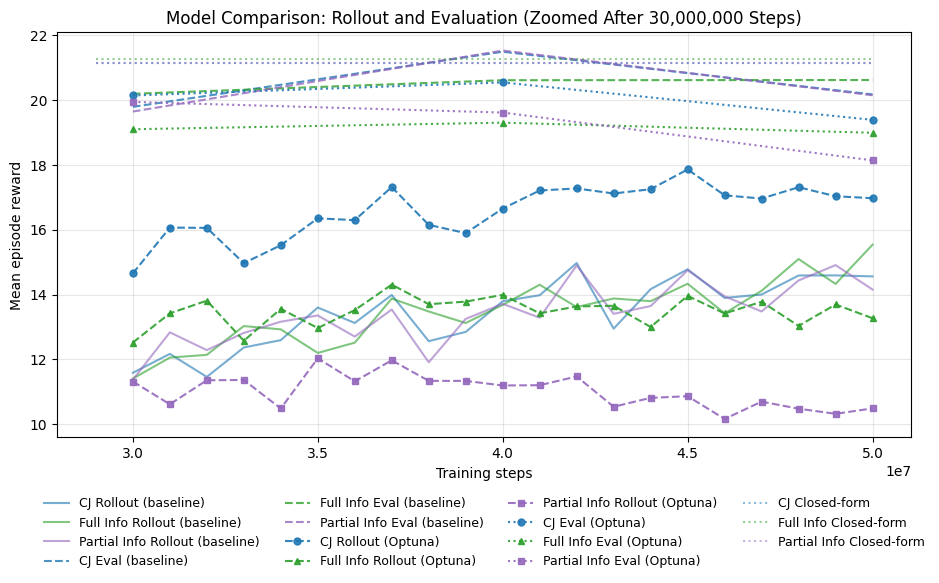

In [33]:
# === Zoomed-in plot after threshold (with evaluation) ===

zoom_threshold = 29_000_000

# --- Helper to filter steps/rewards ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

# --- Baseline zoomed data ---
cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_eval_steps_zoom, cj_eval_rewards_zoom = zoom_filter(cj_eval_steps, cj_eval_rewards, zoom_threshold)
full_eval_steps_zoom, full_eval_rewards_zoom = zoom_filter(full_eval_steps, full_eval_rewards, zoom_threshold)
partial_eval_steps_zoom, partial_eval_rewards_zoom = zoom_filter(partial_eval_steps, partial_eval_rewards, zoom_threshold)

# --- Optuna zoomed data ---
cj_opt_steps_zoom, cj_opt_rewards_zoom = zoom_filter(cj_opt_steps, cj_opt_rewards, zoom_threshold)
full_opt_steps_zoom, full_opt_rewards_zoom = zoom_filter(full_opt_steps, full_opt_rewards, zoom_threshold)
partial_opt_steps_zoom, partial_opt_rewards_zoom = zoom_filter(partial_opt_steps, partial_opt_rewards, zoom_threshold)

cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom = zoom_filter(cj_opt_eval_steps, cj_opt_eval_rewards, zoom_threshold)
full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom = zoom_filter(full_opt_eval_steps, full_opt_eval_rewards, zoom_threshold)
partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom = zoom_filter(partial_opt_eval_steps, partial_opt_eval_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# Baseline eval
if cj_eval_steps_zoom:
    ax.plot(cj_eval_steps_zoom, cj_eval_rewards_zoom, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps_zoom:
    ax.plot(full_eval_steps_zoom, full_eval_rewards_zoom, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps_zoom:
    ax.plot(partial_eval_steps_zoom, partial_eval_rewards_zoom, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps_zoom, cj_opt_rewards_zoom, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_opt_steps_zoom)//15), label='CJ Rollout (Optuna)')
ax.plot(full_opt_steps_zoom, full_opt_rewards_zoom, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_opt_steps_zoom)//15), label='Full Info Rollout (Optuna)')
ax.plot(partial_opt_steps_zoom, partial_opt_rewards_zoom, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_opt_steps_zoom)//15), label='Partial Info Rollout (Optuna)')

# Optuna eval (dotted lines with markers)
if cj_opt_eval_steps_zoom:
    ax.plot(cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_opt_eval_steps_zoom)//15), label='CJ Eval (Optuna)')
if full_opt_eval_steps_zoom:
    ax.plot(full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_opt_eval_steps_zoom)//15), label='Full Info Eval (Optuna)')
if partial_opt_eval_steps_zoom:
    ax.plot(partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_opt_eval_steps_zoom)//15), label='Partial Info Eval (Optuna)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max, linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max, linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max, linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison: Rollout and Evaluation (Zoomed After 30,000,000 Steps)')
ax.legend(
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)
plt.tight_layout()
plt.show()